In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [ ]:
data = {

'CustomerID':[1,2,3,4,5],

'Gender':['Male','Female','Female','Male','Female'],

'Age':[19,21,22,25,30],

'Annual Income (k$)':[15,16,17,18,20],

'Spending Score (1-100)':[39,81,76,40,60]

}

In [ ]:
df = pd.DataFrame(data)

print("\nDATASET")
print(df)


DATASET
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2  Female   21                  16                      81
2           3  Female   22                  17                      76
3           4    Male   25                  18                      40
4           5  Female   30                  20                      60


In [ ]:
original_gender = df['Gender']

encoder = LabelEncoder()

df['Gender_Encoded'] = encoder.fit_transform(df['Gender'])

In [ ]:
X = df[['Gender_Encoded',
        'Age',
        'Annual Income (k$)',
        'Spending Score (1-100)']]

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

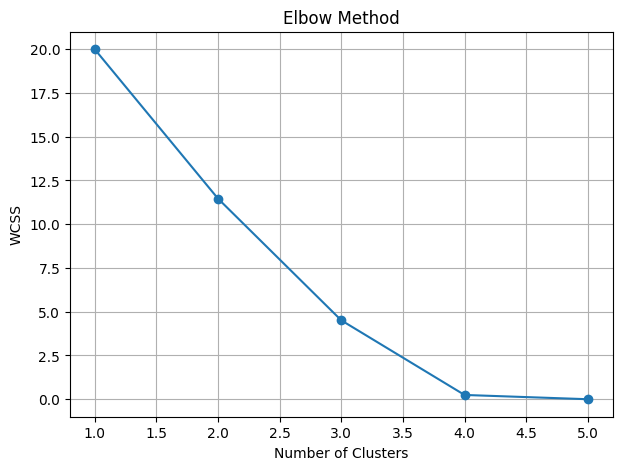

In [ ]:
wcss = []

for i in range(1,6):

    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)
plt.figure(figsize=(7,5))

plt.plot(range(1,6), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)


df['Cluster'] = clusters


df.drop('Gender_Encoded', axis=1, inplace=True)

In [ ]:
print("\nCUSTOMER CLUSTERS")
print(df)


CUSTOMER CLUSTERS
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2  Female   21                  16                      81   
2           3  Female   22                  17                      76   
3           4    Male   25                  18                      40   
4           5  Female   30                  20                      60   

   Cluster  
0        2  
1        0  
2        0  
3        1  
4        1  


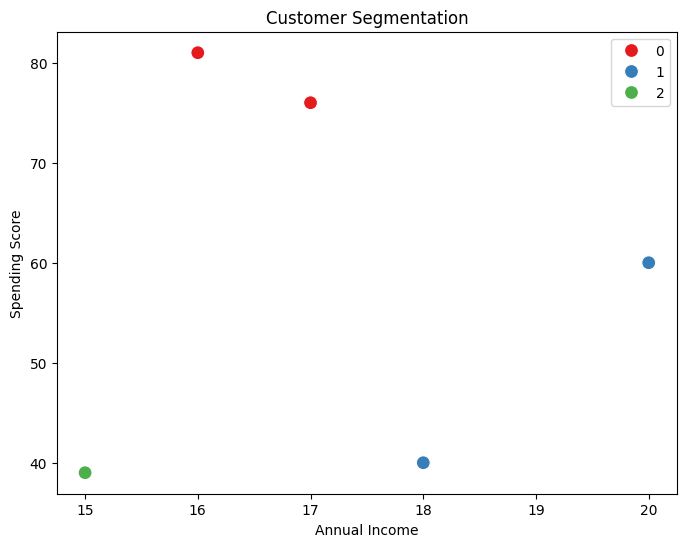

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='Set1',
    s=100
)

plt.title("Customer Segmentation")

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")

plt.legend()

plt.show()

In [ ]:
print("\nCUSTOMER COUNT IN EACH CLUSTER")
print(df['Cluster'].value_counts())

print("\nAVERAGE VALUES")

print(df.groupby('Cluster')[[
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]].mean())

print("\nGENDER DISTRIBUTION")

print(pd.crosstab(df['Cluster'], df['Gender']))


CUSTOMER COUNT IN EACH CLUSTER
Cluster
0    2
1    2
2    1
Name: count, dtype: int64

AVERAGE VALUES
          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
0        21.5                16.5                    78.5
1        27.5                19.0                    50.0
2        19.0                15.0                    39.0

GENDER DISTRIBUTION
Gender   Female  Male
Cluster              
0             2     0
1             1     1
2             0     1
